In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [5]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 210
Kelas: ['anggrek', 'lili', 'matahari']


In [6]:
TARGET_SIZE = (128, 128)

def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)


def median_filter(image_input, kernel_size=5):
    if isinstance(image_input, str):
        img = cv.imread(image_input)
    else:
        img = image_input.copy()

    median_result = cv.medianBlur(img, kernel_size)
    return median_result


def histogram_equalization_grayscale(image_input):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    equalized_result = cv.equalizeHist(img)

    return equalized_result

In [7]:
def prepro(image):
    # Resize + Grayscale
    img = resize_grayscale(image)
    # median_filter
    img = median_filter(img)
    # histogram_equalization_grayscale
    img = histogram_equalization_grayscale(img)
    return img

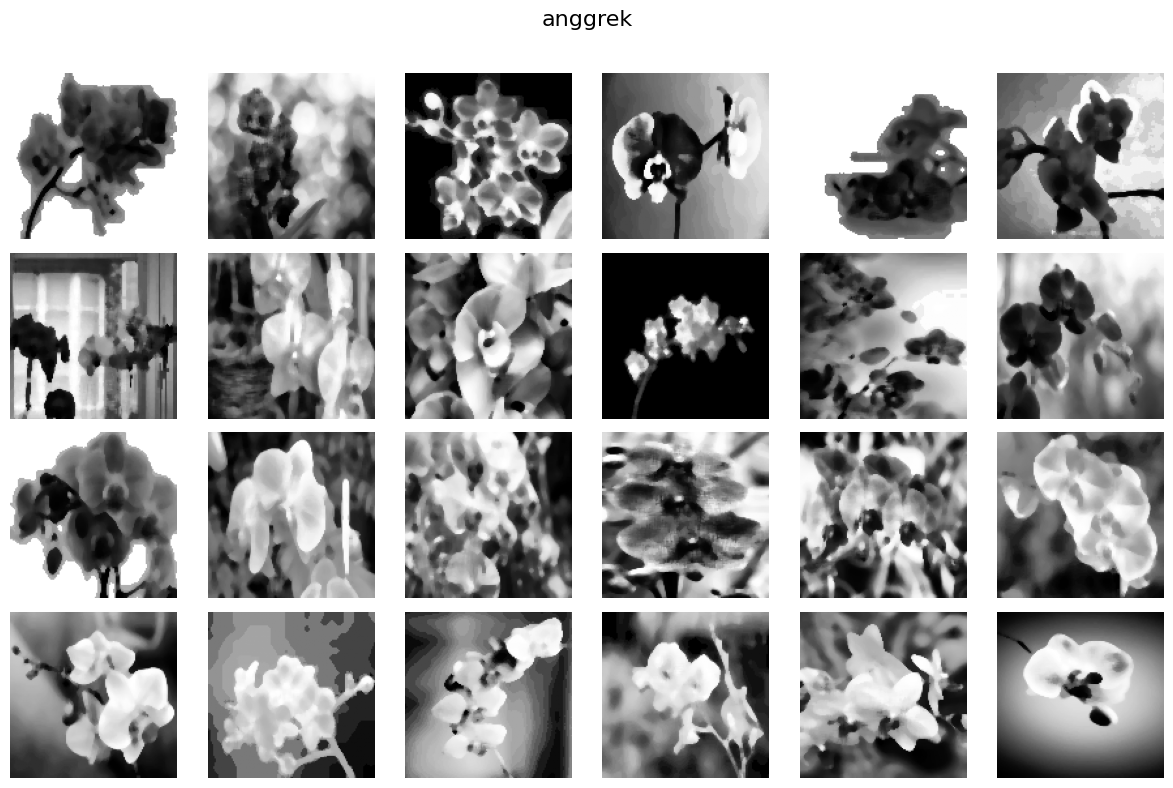

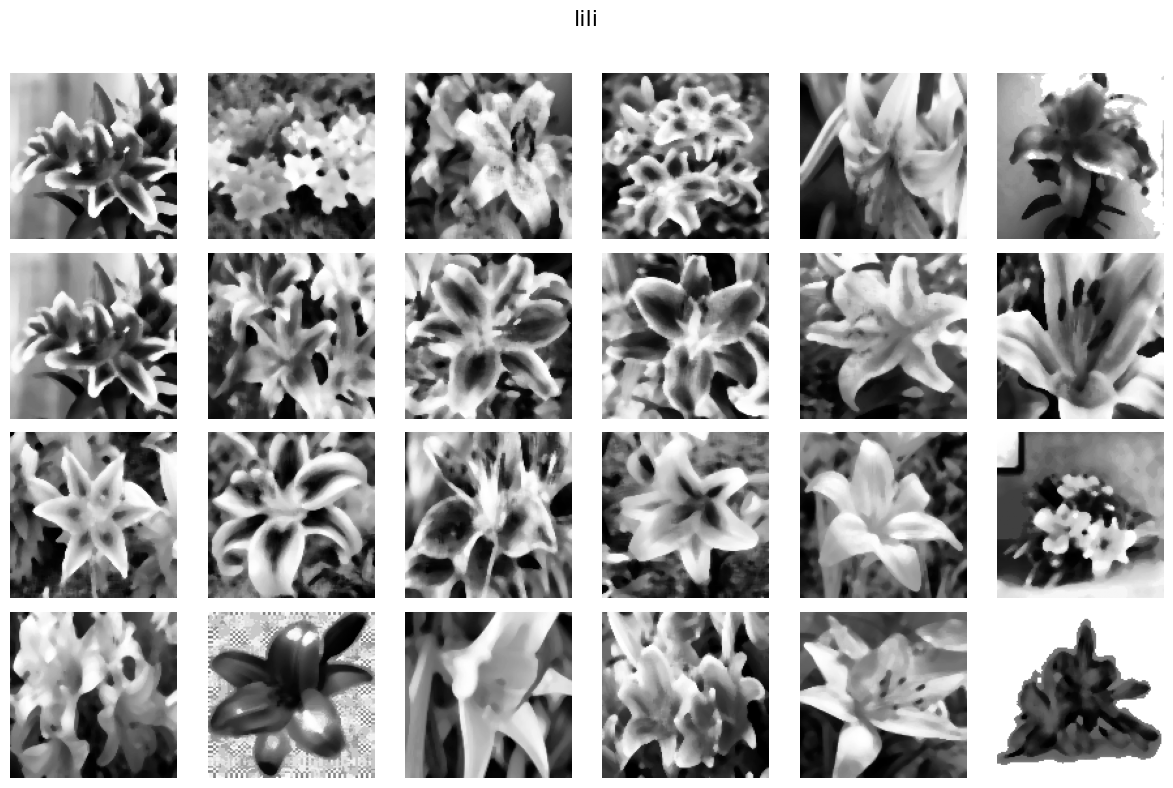

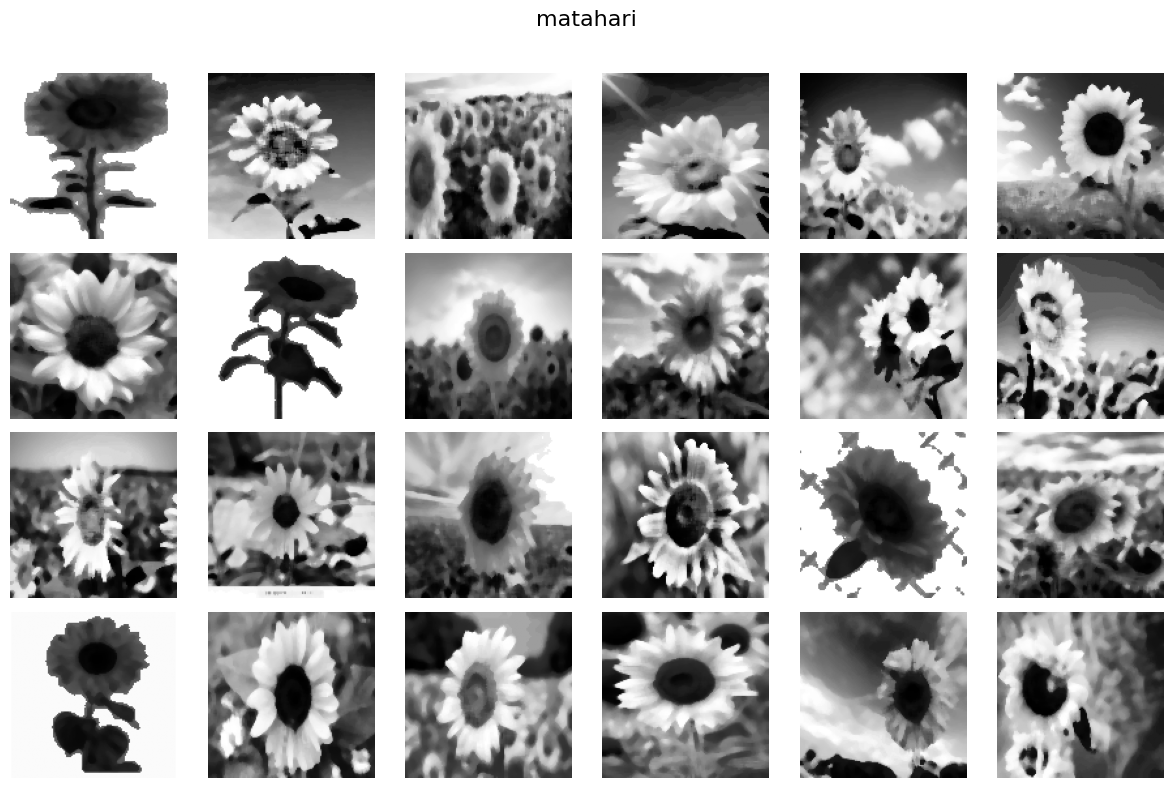

In [8]:
def percobaan2(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan2(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(24, len(idxs))):
        row = k // 6
        col = k % 6
        ax  = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [10]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [11]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [12]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataPreprocessed)} citra.")

Ekstraksi fitur selesai untuk 210 citra.


In [14]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_pros2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_pros2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,anggrek_1.jpg,anggrek,441.327141,672.916486,349.148991,576.233864,0.612232,0.568294,0.634353,0.563526,...,0.177085,0.167790,0.418599,0.408987,0.420814,0.409621,0.975782,0.963031,0.980841,0.968343
1,anggrek_2.jpg,anggrek,191.433440,286.220162,120.362328,250.659185,0.301281,0.243784,0.335861,0.255976,...,0.000991,0.000676,0.029188,0.025677,0.031487,0.025995,0.982522,0.973739,0.988960,0.977002
2,anggrek_3.jpg,anggrek,539.835753,830.713125,502.149114,902.878046,0.500486,0.451145,0.515331,0.448595,...,0.101420,0.095441,0.317638,0.310304,0.318465,0.308935,0.962216,0.941851,0.964884,0.936797
3,anggrek_4.jpg,anggrek,634.718565,818.989274,322.479700,759.498667,0.595889,0.588951,0.721937,0.550706,...,0.013804,0.009613,0.102693,0.103130,0.117490,0.098044,0.941595,0.924941,0.970521,0.930394
4,anggrek_5.jpg,anggrek,233.087906,456.963606,354.913816,463.306591,0.719326,0.639066,0.672319,0.639517,...,0.248092,0.243305,0.501636,0.493513,0.498088,0.493259,0.988108,0.976732,0.981910,0.976409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,matahari_66.jpg,matahari,118.558994,256.064232,180.214075,235.391965,0.480668,0.286124,0.330425,0.295201,...,0.001647,0.001439,0.049657,0.037174,0.040584,0.037933,0.989152,0.976564,0.983497,0.978457
206,matahari_67.jpg,matahari,253.483698,353.116436,167.717028,374.845744,0.302282,0.246461,0.309850,0.221541,...,0.000717,0.000461,0.025887,0.023079,0.026782,0.021480,0.976636,0.967455,0.984619,0.965451
207,matahari_68.jpg,matahari,547.954786,654.145018,239.638472,719.724161,0.546068,0.482040,0.599656,0.484193,...,0.017964,0.014222,0.125879,0.119679,0.134031,0.119257,0.949650,0.940020,0.978060,0.934005
208,matahari_69.jpg,matahari,319.293307,512.406225,329.453986,450.377457,0.567519,0.483146,0.545243,0.496508,...,0.116243,0.111491,0.341435,0.329947,0.340945,0.333903,0.980647,0.968830,0.980028,0.972604


Fitur sebelum seleksi : 28
Fitur setelah seleksi : 13
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Dissimilarity0', 'Dissimilarity45', 'Dissimilarity90', 'ASM0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


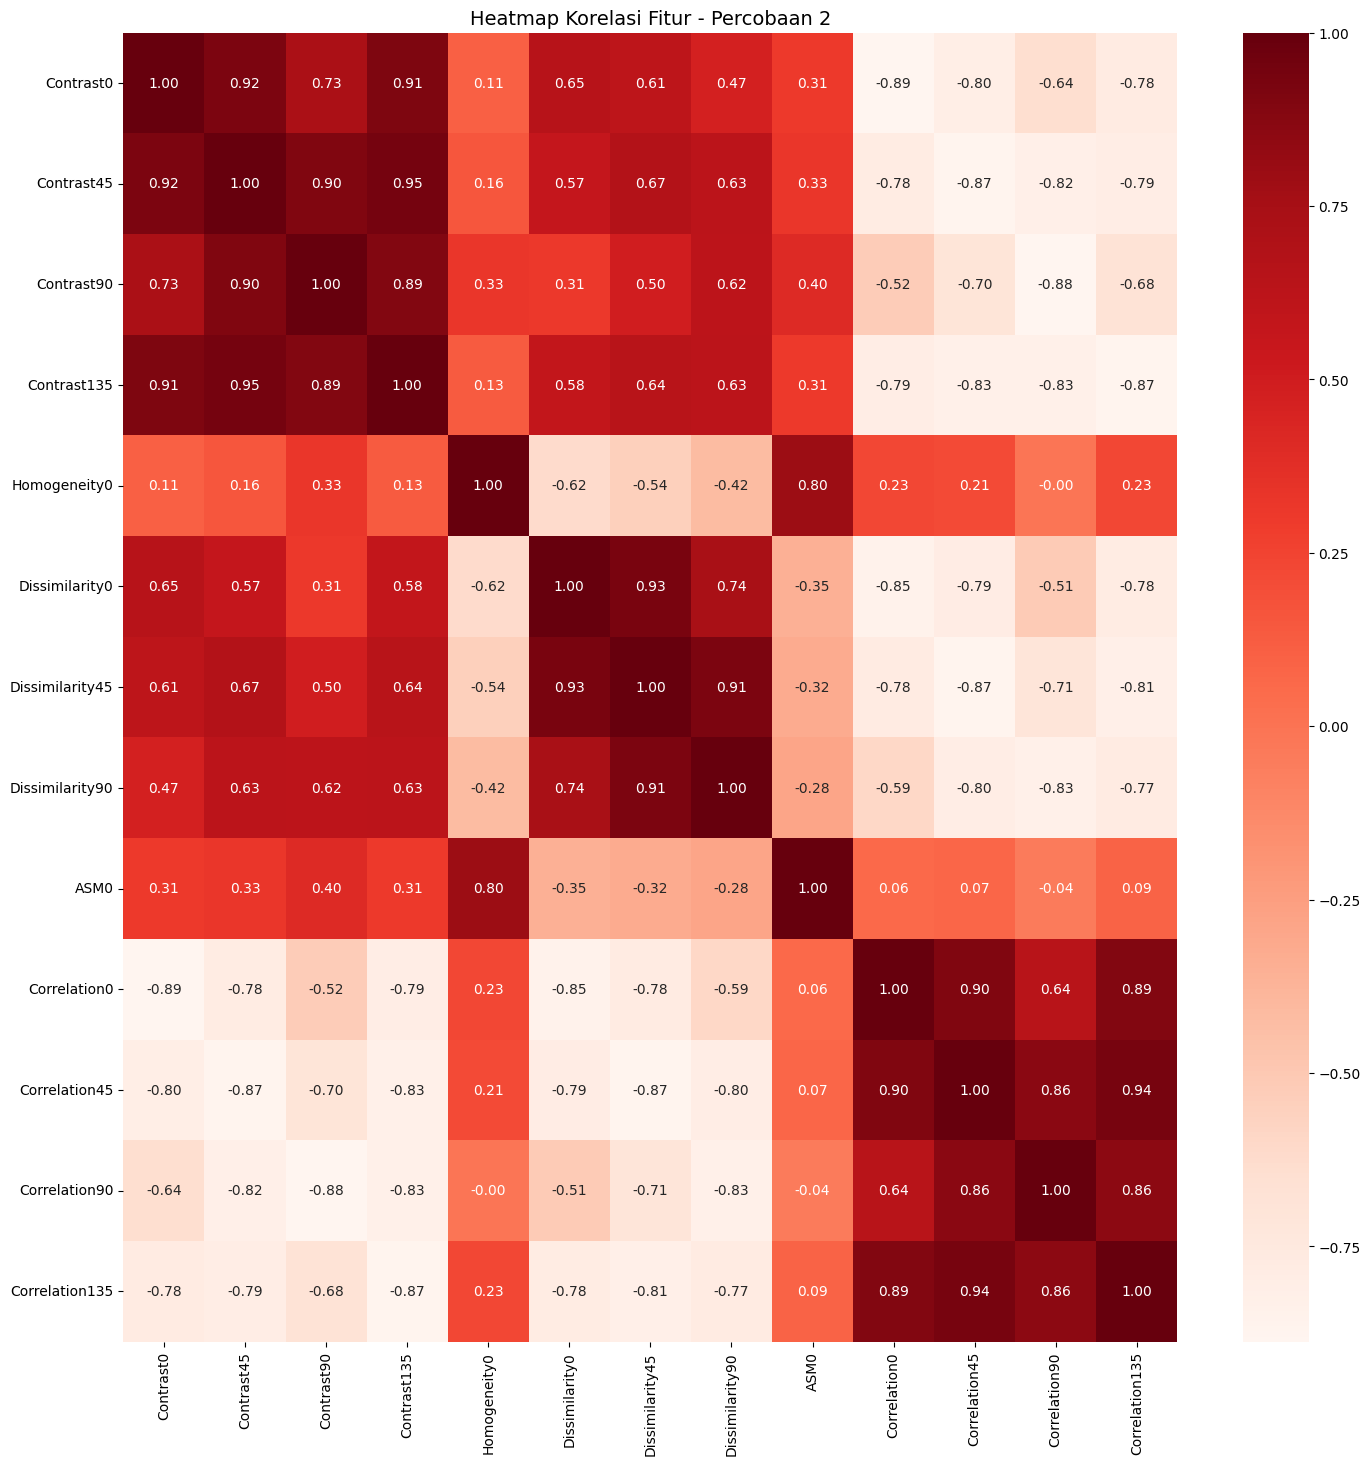

In [16]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Reds', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 2', fontsize=14)
plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(168, 13)
(42, 13)


In [18]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

In [19]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [20]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     anggrek       0.93      0.97      0.95        59
        lili       0.89      0.98      0.93        56
    matahari       0.98      0.83      0.90        53

    accuracy                           0.93       168
   macro avg       0.93      0.93      0.93       168
weighted avg       0.93      0.93      0.93       168

[[57  1  1]
 [ 1 55  0]
 [ 3  6 44]]
Accuracy: 0.9285714285714286

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.37      0.64      0.47        11
        lili       0.56      0.64      0.60        14
    matahari       0.71      0.29      0.42        17

    accuracy                           0.50        42
   macro avg       0.55      0.52      0.49        42
weighted avg       0.57      0.50      0.49        42

[[7 3 1]
 [4 9 1]
 [8 4 5]]
Accuracy: 0.5


In [21]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     anggrek       0.61      0.75      0.67        59
        lili       0.71      0.70      0.70        56
    matahari       0.61      0.47      0.53        53

    accuracy                           0.64       168
   macro avg       0.64      0.64      0.64       168
weighted avg       0.64      0.64      0.64       168

[[44  6  9]
 [10 39  7]
 [18 10 25]]
Accuracy: 0.6428571428571429

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.33      0.55      0.41        11
        lili       0.50      0.57      0.53        14
    matahari       0.50      0.24      0.32        17

    accuracy                           0.43        42
   macro avg       0.44      0.45      0.42        42
weighted avg       0.46      0.43      0.42        42

[[6 3 2]
 [4 8 2]
 [8 5 4]]
Accuracy: 0.42857142857142855


In [22]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     anggrek       0.67      0.75      0.70        59
        lili       0.66      0.77      0.71        56
    matahari       0.68      0.47      0.56        53

    accuracy                           0.67       168
   macro avg       0.67      0.66      0.66       168
weighted avg       0.67      0.67      0.66       168

[[44  7  8]
 [ 9 43  4]
 [13 15 25]]
Accuracy: 0.6666666666666666

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.33      0.55      0.41        11
        lili       0.50      0.57      0.53        14
    matahari       0.62      0.29      0.40        17

    accuracy                           0.45        42
   macro avg       0.49      0.47      0.45        42
weighted avg       0.51      0.45      0.45        42

[[6 4 1]
 [4 8 2]
 [8 4 5]]
Accuracy: 0.4523809523809524


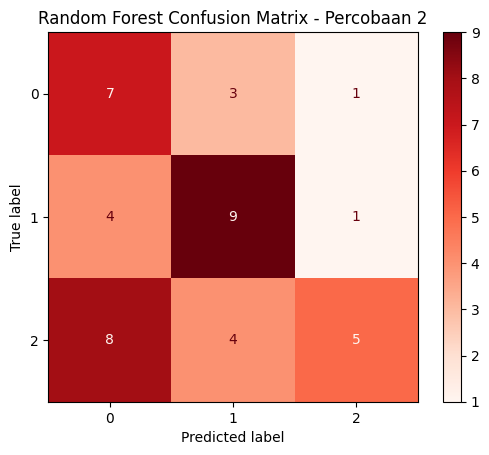

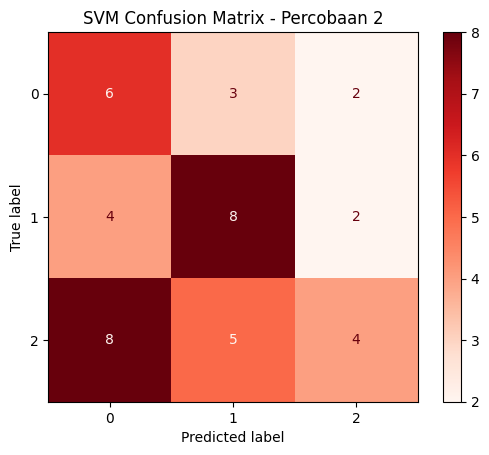

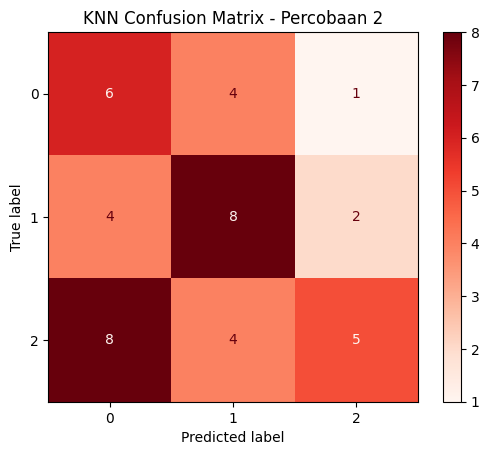

In [23]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Reds)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan 2")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan 2")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan 2")

In [25]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('hasil_klasifikasi_pros2.csv', index=False)
print("✅ File hasil_klasifikasi_pros2.csv berhasil disimpan!")
df_hasil

✅ File hasil_klasifikasi_pros2.csv berhasil disimpan!


,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.928571,0.500000,0.573107,0.500000,0.490873
1,SVM,0.642857,0.428571,0.456349,0.428571,0.415676
2,KNN,0.666667,0.452381,0.506944,0.452381,0.448057
